# 04 Evaluation — All 18 Folds Using Engineer 3 Thresholds

This Kaggle notebook evaluates the supervised defect-detection checkpoints using:

- Dataset: `manuelgamal/mvtec-subset`
- Checkpoints dataset: `ssidds-checkpoints`
- 6 categories × 3 folds = **18 fold evaluations**
- Engineer 3 category thresholds:
  - bottle: `0.3924`
  - capsule: `0.4337`
  - carpet: `0.4542`
  - hazelnut: `0.3982`
  - leather: `0.4731`
  - pill: `0.4564`

Important change:

- This notebook does **not** choose new thresholds from the test set.
- It uses Engineer 3's validation-set F1-optimal category thresholds.
- It evaluates and displays **all 3 folds for each category**.

Outputs are saved to:

```text
/kaggle/working/eval_results_all_folds/
```


In [1]:
# =========================
# Parameters
# =========================

from pathlib import Path

CATEGORIES = ["bottle", "capsule", "carpet", "hazelnut", "leather", "pill"]
FOLD_IDS = [1, 2, 3]

# Kaggle checkpoint folders are usually fold_0, fold_1, fold_2.
# In tables/reports we display folds as 1, 2, 3.
FOLD_ZERO_INDEXED = {1: 0, 2: 1, 3: 2}

# Engineer 3 thresholds.
# These are category-level thresholds from validation F1-optimal search.
ENGINEER3_THRESHOLDS = {
    "bottle": 0.3924,
    "capsule": 0.4337,
    "carpet": 0.4542,
    "hazelnut": 0.3982,
    "leather": 0.4731,
    "pill": 0.4564,
}

# Bootstrap settings.
# Keep 10_000 for final results. For quick debugging, temporarily set to 200.
N_BOOTSTRAP = 10_000
BOOTSTRAP_SEED = 42

# Qualitative Grad-CAM galleries are optional and can be slow for all 18 folds.
# Set to True if you also want Grad-CAM and failure-case galleries.
RUN_QUALITATIVE = False
QUAL_N_PER_CLASS = 2
QUAL_N_WORST = 8

KAGGLE_INPUT = Path("/kaggle/input")
OUTPUT_DIR = Path("/kaggle/working/eval_results_all_folds")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Configured categories:", CATEGORIES)
print("Engineer 3 thresholds:", ENGINEER3_THRESHOLDS)
print("Bootstrap resamples:", N_BOOTSTRAP)
print("Run qualitative:", RUN_QUALITATIVE)
print("Output directory:", OUTPUT_DIR)


Configured categories: ['bottle', 'capsule', 'carpet', 'hazelnut', 'leather', 'pill']
Engineer 3 thresholds: {'bottle': 0.3924, 'capsule': 0.4337, 'carpet': 0.4542, 'hazelnut': 0.3982, 'leather': 0.4731, 'pill': 0.4564}
Bootstrap resamples: 10000
Run qualitative: False
Output directory: /kaggle/working/eval_results_all_folds


## 1. Clone repo and install minimal dependencies

Use **Kaggle T4 GPU** if possible.

The notebook installs only the minimal packages needed and uses `--no-deps` to avoid downgrading Kaggle's preinstalled scientific stack.


In [2]:
import os
import sys
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/ManuelGamal/Self-Supervised-Industrial-Defect-Detection-System.git"
REPO_DIR = Path("/kaggle/working/Self-Supervised-Industrial-Defect-Detection-System")

if not REPO_DIR.exists():
    print("Cloning repository...")
    subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
else:
    print("Repository already exists. Pulling latest changes...")
    subprocess.run(["git", "-C", str(REPO_DIR), "pull"], check=False)

sys.path.insert(0, str(REPO_DIR))

packages = [
    "pytorch-lightning==2.3.0",
    "torchmetrics==1.4.0",
    "timm==1.0.7",
    "grad-cam==1.5.0",
    "lightning-utilities",
    "ttach",
]

print("Installing minimal dependencies...")
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "--no-deps", *packages],
    check=False,
)

print("Repo ready:", REPO_DIR)


Cloning repository...


Cloning into '/kaggle/working/Self-Supervised-Industrial-Defect-Detection-System'...
Updating files: 100% (113/113), done.


Installing minimal dependencies...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.5/47.5 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 812.2/812.2 kB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 868.8/868.8 kB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 79.4 MB/s eta 0:00:00
Repo ready: /kaggle/working/Self-Supervised-Industrial-Defect-Detection-System


In [3]:
# =========================
# Imports
# =========================

import csv
import json
import warnings
import time
from datetime import timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision.transforms as T
from PIL import Image
from torch.utils.data import DataLoader, Dataset

from src.evaluation.bootstrap import bootstrap_ci
from src.evaluation.metrics import (
    compute_accuracy,
    compute_aupr,
    compute_auroc,
    compute_f1,
)
from src.evaluation.evaluator import save_diagnostic_plots
from src.models.lit_module import DefectClassifier

try:
    from src.evaluation.qualitative import run_qualitative_for_category
    QUALITATIVE_AVAILABLE = True
except Exception as e:
    print("Qualitative import failed:", repr(e))
    QUALITATIVE_AVAILABLE = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


Device: cuda
Torch: 2.10.0+cu128
CUDA available: True


## 2. Detect Kaggle input paths

Attach these datasets on the right panel:

1. `MVTec Subset`
2. `ssidds-checkpoints`

The notebook auto-detects the actual mounted paths under `/kaggle/input`.


In [4]:
def find_mvtec_root() -> Path:
    """Find the MVTec subset root containing the six category folders."""
    direct_candidates = [
        KAGGLE_INPUT / "mvtec-subset",
        KAGGLE_INPUT / "datasets" / "manuelgamal" / "mvtec-subset",
    ]

    for candidate in direct_candidates:
        if candidate.exists() and all((candidate / c).exists() for c in CATEGORIES):
            return candidate

    for path in KAGGLE_INPUT.rglob("*"):
        if path.is_dir() and all((path / c).exists() for c in CATEGORIES):
            return path

    raise FileNotFoundError(
        "Could not find MVTec subset root. Attach Kaggle dataset "
        "`manuelgamal/mvtec-subset`."
    )


def find_checkpoint_root() -> Path:
    """Find the checkpoint dataset root containing .ckpt files."""
    direct_candidates = [
        KAGGLE_INPUT / "ssidds-checkpoints",
        KAGGLE_INPUT / "datasets" / "manuelgamal" / "ssidds-checkpoints",
    ]

    for candidate in direct_candidates:
        if candidate.exists() and list(candidate.rglob("*.ckpt")):
            return candidate

    for path in KAGGLE_INPUT.iterdir():
        if path.is_dir() and list(path.rglob("*.ckpt")):
            return path

    raise FileNotFoundError(
        "Could not find checkpoint dataset. Attach `ssidds-checkpoints` "
        "with the 18 .ckpt files."
    )


MVTEC_ROOT = find_mvtec_root()
CHECKPOINT_ROOT = find_checkpoint_root()
SPLITS_ROOT = REPO_DIR / "data" / "splits"

print("MVTec root:", MVTEC_ROOT)
print("Checkpoint root:", CHECKPOINT_ROOT)
print("Splits root:", SPLITS_ROOT)
print("Number of .ckpt files found:", len(list(CHECKPOINT_ROOT.rglob("*.ckpt"))))


MVTec root: /kaggle/input/datasets/manuelgamal/mvtec-subset
Checkpoint root: /kaggle/input/datasets/manuelgamal/ssidds-checkpoints
Splits root: /kaggle/working/Self-Supervised-Industrial-Defect-Detection-System/data/splits
Number of .ckpt files found: 18


## 3. Dataset helpers

This notebook uses a custom CSV-based dataset that returns normal dictionaries, not `Sample` dataclasses.

That avoids the previous DataLoader error:

```text
default_collate: batch must contain tensors, numpy arrays, numbers, dicts or lists; found <class 'src.types.Sample'>
```

If the split CSV is missing, the notebook falls back to the standard MVTec test folder structure.


In [5]:
DEFAULT_TRANSFORM = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class CSVSplitTestDataset(Dataset):
    """CSV-driven test dataset returning dictionaries.

    This intentionally does not use src.data.MVTecDataset because that dataset
    returns src.types.Sample objects, which require a custom collate function.
    Returning dictionaries avoids DataLoader collation errors.
    """

    def __init__(self, root: Path, category: str, split_csv: Path, transform=None):
        self.root = Path(root)
        self.category = category
        self.split_csv = Path(split_csv)
        self.transform = transform or DEFAULT_TRANSFORM
        self.samples = []

        with open(self.split_csv, newline="", encoding="utf-8") as fh:
            reader = csv.DictReader(fh)
            for row in reader:
                if row.get("category") != category:
                    continue
                if row.get("split") != "test":
                    continue
                self.samples.append({
                    "image_path": row["image_path"],
                    "label": int(row["label"]),
                    "category": row.get("category", category),
                })

        if not self.samples:
            raise ValueError(
                f"No test rows found for category={category} in split CSV: {split_csv}"
            )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        image_path = Path(item["image_path"])
        if not image_path.is_absolute():
            image_path = self.root / image_path

        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)

        return {
            "image": image,
            "label": torch.tensor(item["label"], dtype=torch.long),
            "category": item["category"],
            "path": str(image_path),
        }


class SimpleMVTecTestDataset(Dataset):
    """Fallback dataset using category/test/* folders."""

    def __init__(self, root: Path, category: str, transform=None):
        self.root = Path(root)
        self.category = category
        self.transform = transform or DEFAULT_TRANSFORM
        self.samples = []

        test_root = self.root / category / "test"
        if not test_root.exists():
            raise FileNotFoundError(f"Missing test folder: {test_root}")

        for defect_type in sorted(test_root.iterdir()):
            if not defect_type.is_dir():
                continue
            label = 0 if defect_type.name == "good" else 1
            for image_path in sorted(defect_type.glob("*.png")):
                self.samples.append({
                    "image_path": image_path,
                    "label": label,
                    "category": category,
                })

        if not self.samples:
            raise FileNotFoundError(f"No PNG test images found under {test_root}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        image_path = Path(item["image_path"])
        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)

        return {
            "image": image,
            "label": torch.tensor(item["label"], dtype=torch.long),
            "category": item["category"],
            "path": str(image_path),
        }


def find_split_csv(category: str, fold_id: int) -> Path | None:
    """Find split CSV for a category/fold.

    The repository currently may only contain category-level split files like
    bottle_100pct_seed42.csv. If fold-specific CSVs are absent, this function
    uses that category-level file so all 3 checkpoints are evaluated on the
    same held-out test split.
    """
    z = FOLD_ZERO_INDEXED[fold_id]

    candidates = [
        SPLITS_ROOT / f"{category}_fold{z}.csv",
        SPLITS_ROOT / f"{category}_fold_{z}.csv",
        SPLITS_ROOT / f"{category}_100pct_fold{z}.csv",
        SPLITS_ROOT / f"{category}_100pct_fold_{z}.csv",
        SPLITS_ROOT / f"{category}_fold{fold_id}.csv",
        SPLITS_ROOT / f"{category}_fold_{fold_id}.csv",
        SPLITS_ROOT / f"{category}_100pct_fold{fold_id}.csv",
        SPLITS_ROOT / f"{category}_100pct_fold_{fold_id}.csv",
        SPLITS_ROOT / f"{category}_100pct_seed42.csv",
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    for csv_path in SPLITS_ROOT.rglob("*.csv"):
        name = csv_path.name.lower()
        if category.lower() in name and "100pct" in name:
            return csv_path

    return None


def build_test_dataloader(category: str, fold_id: int, batch_size: int = 32) -> tuple[DataLoader, str]:
    """Build test dataloader for one category/fold."""
    split_csv = find_split_csv(category, fold_id)

    if split_csv is not None:
        try:
            dataset = CSVSplitTestDataset(
                root=MVTEC_ROOT,
                category=category,
                split_csv=split_csv,
                transform=DEFAULT_TRANSFORM,
            )
            loader = DataLoader(
                dataset,
                batch_size=batch_size,
                shuffle=False,
                num_workers=0,
            )
            return loader, f"csv:{split_csv}"
        except Exception as e:
            warnings.warn(
                f"Could not use split CSV {split_csv}: {e}. "
                "Falling back to standard MVTec test folder."
            )

    dataset = SimpleMVTecTestDataset(MVTEC_ROOT, category, transform=DEFAULT_TRANSFORM)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )
    return loader, "fallback:standard_mvtec_test_folder"


## 4. Checkpoint helpers

The checkpoints usually live in folders like:

```text
checkpoints/supervised/bottle/fold_0/best.ckpt
checkpoints/supervised/bottle/fold_1/best.ckpt
checkpoints/supervised/bottle/fold_2/best.ckpt
```

The notebook displays these as folds 1, 2, and 3.


In [6]:
def path_has_folder(path: Path, folder_name: str) -> bool:
    return any(part.lower() == folder_name.lower() for part in path.parts)


def find_checkpoint(category: str, fold_id: int) -> Path:
    """Find the checkpoint for category and displayed fold id 1/2/3."""
    zero_fold = FOLD_ZERO_INDEXED[fold_id]
    all_ckpts = sorted(CHECKPOINT_ROOT.rglob("*.ckpt"))

    category_matches = [
        path for path in all_ckpts
        if category.lower() in str(path).lower()
    ]

    if not category_matches:
        raise FileNotFoundError(
            f"No checkpoint found for category `{category}` under {CHECKPOINT_ROOT}."
        )

    # Prefer exact zero-indexed fold folder first.
    zero_folder = f"fold_{zero_fold}"
    zero_matches = [p for p in category_matches if path_has_folder(p, zero_folder)]

    if zero_matches:
        best = [p for p in zero_matches if p.name.lower() == "best.ckpt"]
        return best[0] if best else zero_matches[0]

    # Fallback: one-indexed folder if the dataset uses fold_1/fold_2/fold_3.
    one_folder = f"fold_{fold_id}"
    one_matches = [p for p in category_matches if path_has_folder(p, one_folder)]

    if one_matches:
        best = [p for p in one_matches if p.name.lower() == "best.ckpt"]
        return best[0] if best else one_matches[0]

    raise FileNotFoundError(
        f"No checkpoint found for category={category}, fold={fold_id}. "
        f"Candidates: {[str(p) for p in category_matches[:10]]}"
    )


# Sanity check table before running evaluation
sanity_rows = []

for category in CATEGORIES:
    for fold_id in FOLD_IDS:
        split_csv = find_split_csv(category, fold_id)
        dataloader_source = None
        n_test = None
        n_pos = None
        n_neg = None

        try:
            loader, dataloader_source = build_test_dataloader(category, fold_id)
            dataset = loader.dataset
            labels = [int(dataset[i]["label"]) for i in range(len(dataset))]
            n_test = len(labels)
            n_pos = int(np.sum(np.array(labels) == 1))
            n_neg = int(np.sum(np.array(labels) == 0))
        except Exception as e:
            dataloader_source = f"ERROR: {repr(e)}"

        try:
            checkpoint = find_checkpoint(category, fold_id)
            checkpoint_ok = True
        except Exception as e:
            checkpoint = str(e)
            checkpoint_ok = False

        sanity_rows.append({
            "category": category,
            "fold": fold_id,
            "checkpoint_folder": f"fold_{FOLD_ZERO_INDEXED[fold_id]}",
            "threshold": ENGINEER3_THRESHOLDS[category],
            "split_csv_found": split_csv is not None,
            "split_csv": str(split_csv) if split_csv else None,
            "dataloader_source": dataloader_source,
            "n_test": n_test,
            "n_positive": n_pos,
            "n_negative": n_neg,
            "checkpoint_found": checkpoint_ok,
            "checkpoint": str(checkpoint),
        })

sanity_df = pd.DataFrame(sanity_rows)
display(sanity_df)


,category,fold,checkpoint_folder,threshold,split_csv_found,split_csv,dataloader_source,n_test,n_positive,n_negative,checkpoint_found,checkpoint
0,bottle,1,fold_0,0.3924,True,/kaggle/working/Self-Supervised-Industrial-Def...,csv:/kaggle/working/Self-Supervised-Industrial...,44,9,35,True,/kaggle/input/datasets/manuelgamal/ssidds-chec...
1,bottle,2,fold_1,0.3924,True,/kaggle/working/Self-Supervised-Industrial-Def...,csv:/kaggle/working/Self-Supervised-Industrial...,44,9,35,True,/kaggle/input/datasets/manuelgamal/ssidds-chec...
2,bottle,3,fold_2,0.3924,True,/kaggle/working/Self-Supervised-Industrial-Def...,csv:/kaggle/working/Self-Supervised-Industrial...,44,9,35,True,/kaggle/input/datasets/manuelgamal/ssidds-chec...
3,capsule,1,fold_0,0.4337,True,/kaggle/working/Self-Supervised-Industrial-Def...,csv:/kaggle/working/Self-Supervised-Industrial...,53,16,37,True,/kaggle/input/datasets/manuelgamal/ssidds-chec...
4,capsule,2,fold_1,0.4337,True,/kaggle/working/Self-Supervised-Industrial-Def...,csv:/kaggle/working/Self-Supervised-Industrial...,53,16,37,True,/kaggle/input/datasets/manuelgamal/ssidds-chec...
5,capsule,3,fold_2,0.4337,True,/kaggle/working/Self-Supervised-Industrial-Def...,csv:/kaggle/working/Self-Supervised-Industrial...,53,16,37,True,/kaggle/input/datasets/manuelgamal/ssidds-chec...
6,carpet,1,fold_0,0.4542,True,/kaggle/working/Self-Supervised-Industrial-Def...,csv:/kaggle/working/Self-Supervised-Industrial...,60,13,47,True,/kaggle/input/datasets/manuelgamal/ssidds-chec...
7,carpet,2,fold_1,0.4542,True,/kaggle/working/Self-Supervised-Industrial-Def...,csv:/kaggle/working/Self-Supervised-Industrial...,60,13,47,True,/kaggle/input/datasets/manuelgamal/ssidds-chec...
8,carpet,3,fold_2,0.4542,True,/kaggle/working/Self-Supervised-Industrial-Def...,csv:/kaggle/working/Self-Supervised-Industrial...,60,13,47,True,/kaggle/input/datasets/manuelgamal/ssidds-chec...
9,hazelnut,1,fold_0,0.3982,True,/kaggle/working/Self-Supervised-Industrial-Def...,csv:/kaggle/working/Self-Supervised-Industrial...,76,11,65,True,/kaggle/input/datasets/manuelgamal/ssidds-chec...


## 5. Fixed-threshold evaluation

This section uses Engineer 3 thresholds directly.

It does **not** call `compute_f1_optimal()` on the test set.


In [13]:
@torch.no_grad()
def run_inference_dict(model: torch.nn.Module, dataloader: DataLoader, device: str = "cpu") -> tuple[np.ndarray, np.ndarray]:
    """Run inference on dictionary batches and return y_true, y_score."""
    model.eval()
    model.to(device)

    all_labels = []
    all_scores = []

    for batch in dataloader:
        images = batch["image"].to(device)
        labels = batch["label"]

        logits = model(images)
        probs = torch.softmax(logits, dim=1)[:, 1]

        all_scores.extend(probs.detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().astype(int).tolist())

    return np.asarray(all_labels, dtype=int), np.asarray(all_scores, dtype=float)


def safe_bootstrap_ci(y_true, y_score, metric_fn, n_resamples=N_BOOTSTRAP, seed=BOOTSTRAP_SEED):
    return bootstrap_ci(
        y_true=np.asarray(y_true),
        y_score=np.asarray(y_score),
        metric_fn=metric_fn,
        n_resamples=n_resamples,
        confidence=0.95,
        seed=seed,
    )


def evaluate_arrays_with_fixed_threshold(y_true: np.ndarray, y_score: np.ndarray, threshold: float) -> dict:
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.asarray(y_score, dtype=float)

    def f1_fixed(yt, ys):
        return compute_f1(yt, ys, threshold=threshold)

    def accuracy_fixed(yt, ys):
        return compute_accuracy(yt, ys, threshold=threshold)

    auroc, auroc_lo, auroc_hi = safe_bootstrap_ci(y_true, y_score, compute_auroc)
    aupr, aupr_lo, aupr_hi = safe_bootstrap_ci(y_true, y_score, compute_aupr)
    f1, f1_lo, f1_hi = safe_bootstrap_ci(y_true, y_score, f1_fixed)
    accuracy, accuracy_lo, accuracy_hi = safe_bootstrap_ci(y_true, y_score, accuracy_fixed)

    return {
        "auroc": float(auroc),
        "auroc_ci_low": float(auroc_lo),
        "auroc_ci_high": float(auroc_hi),
        "aupr": float(aupr),
        "aupr_ci_low": float(aupr_lo),
        "aupr_ci_high": float(aupr_hi),
        "f1": float(f1),
        "f1_ci_low": float(f1_lo),
        "f1_ci_high": float(f1_hi),
        "accuracy": float(accuracy),
        "accuracy_ci_low": float(accuracy_lo),
        "accuracy_ci_high": float(accuracy_hi),
        "threshold": float(threshold),
        "n_samples": int(len(y_true)),
        "n_positive": int(np.sum(y_true == 1)),
        "n_negative": int(np.sum(y_true == 0)),
    }


def save_predictions_csv(y_true: np.ndarray, y_score: np.ndarray, threshold: float, output_path: Path) -> None:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    y_pred = (np.asarray(y_score) >= threshold).astype(int)

    pred_df = pd.DataFrame({
        "y_true": y_true,
        "y_score": y_score,
        "y_pred": y_pred,
        "threshold": threshold,
    })
    pred_df.to_csv(output_path, index=False)


def safe_to_markdown(df: pd.DataFrame, path: Path) -> None:
    """Write markdown if tabulate is available, otherwise write CSV-style text."""
    try:
        df.to_markdown(path, index=False)
    except Exception:
        path.write_text(df.to_csv(index=False), encoding="utf-8")


def evaluate_one_fold(category: str, fold_id: int) -> dict:
    threshold = ENGINEER3_THRESHOLDS[category]
    fold_output = OUTPUT_DIR / category / f"fold{fold_id}"
    fold_output.mkdir(parents=True, exist_ok=True)

    dataloader, split_source = build_test_dataloader(category, fold_id)
    checkpoint_path = find_checkpoint(category, fold_id)

    print(f"\\n{'=' * 80}")
    print(f"Evaluating category={category}, fold={fold_id}")
    print(f"Checkpoint folder: fold_{FOLD_ZERO_INDEXED[fold_id]}")
    print(f"Threshold: {threshold}")
    print(f"Checkpoint: {checkpoint_path}")
    print(f"Split source: {split_source}")
    print(f"Output: {fold_output}")
    print(f"{'=' * 80}")

    model = DefectClassifier.load_from_checkpoint(checkpoint_path, map_location=DEVICE)
    y_true, y_score = run_inference_dict(model, dataloader, device=DEVICE)

    metrics = evaluate_arrays_with_fixed_threshold(y_true, y_score, threshold)

    save_diagnostic_plots(
        y_true=y_true,
        y_score=y_score,
        threshold=threshold,
        output_dir=fold_output,
        title_prefix=f"{category} fold {fold_id} — ",
    )

    save_predictions_csv(
        y_true=y_true,
        y_score=y_score,
        threshold=threshold,
        output_path=fold_output / "predictions.csv",
    )

    row = {
        "category": category,
        "fold": fold_id,
        "checkpoint_folder": f"fold_{FOLD_ZERO_INDEXED[fold_id]}",
        "threshold_source": "Engineer 3 validation F1-optimal category threshold",
        "checkpoint_path": str(checkpoint_path),
        "split_source": split_source,
        **metrics,
    }

    with open(fold_output / "metrics.json", "w", encoding="utf-8") as f:
        json.dump(row, f, indent=2)

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(
        f"AUROC={row['auroc']:.4f}, AUPR={row['aupr']:.4f}, "
        f"F1={row['f1']:.4f}, ACC={row['accuracy']:.4f}, "
        f"n={row['n_samples']}"
    )

    return row


## 6. Run quantitative evaluation for all 18 folds

In [14]:
start_time = time.time()

all_rows = []
errors = []

for category in CATEGORIES:
    for fold_id in FOLD_IDS:
        try:
            row = evaluate_one_fold(category, fold_id)
            all_rows.append(row)
        except Exception as e:
            error = {
                "category": category,
                "fold": fold_id,
                "error": repr(e),
            }
            print(f"ERROR category={category}, fold={fold_id}: {repr(e)}")
            errors.append(error)

elapsed = time.time() - start_time
print(f"\\nFinished quantitative evaluation in {timedelta(seconds=int(elapsed))}")
print(f"Successful folds: {len(all_rows)} / 18")
print(f"Errors: {len(errors)}")

if errors:
    error_df = pd.DataFrame(errors)
    error_df.to_csv(OUTPUT_DIR / "errors.csv", index=False)
    display(error_df)

all_folds_df = pd.DataFrame(all_rows)

if len(all_folds_df) > 0:
    all_folds_df = all_folds_df.sort_values(["category", "fold"]).reset_index(drop=True)

    all_folds_df.to_csv(OUTPUT_DIR / "all_folds_results.csv", index=False)
    all_folds_df.to_json(OUTPUT_DIR / "all_folds_results.json", orient="records", indent=2)
    safe_to_markdown(all_folds_df, OUTPUT_DIR / "all_folds_results.md")

    display_cols = [
        "category", "fold", "checkpoint_folder", "threshold",
        "auroc", "aupr", "f1", "accuracy",
        "n_samples", "n_positive", "n_negative",
    ]
    display(all_folds_df[display_cols])
else:
    print("No successful folds. Check errors.csv for details.")


\n================================================================================
Evaluating category=bottle, fold=1
Checkpoint folder: fold_0
Threshold: 0.3924
Checkpoint: /kaggle/input/datasets/manuelgamal/ssidds-checkpoints/checkpoints/supervised/bottle/fold_0/best.ckpt
Split source: csv:/kaggle/working/Self-Supervised-Industrial-Defect-Detection-System/data/splits/bottle_100pct_seed42.csv
Output: /kaggle/working/eval_results_all_folds/bottle/fold1


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.6.1, which is newer than your current Lightning version: v2.3.0


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

AUROC=0.9841, AUPR=0.9603, F1=0.8750, ACC=0.9545, n=44
\n================================================================================
Evaluating category=bottle, fold=2
Checkpoint folder: fold_1
Threshold: 0.3924
Checkpoint: /kaggle/input/datasets/manuelgamal/ssidds-checkpoints/checkpoints/supervised/bottle/fold_1/best.ckpt
Split source: csv:/kaggle/working/Self-Supervised-Industrial-Defect-Detection-System/data/splits/bottle_100pct_seed42.csv
Output: /kaggle/working/eval_results_all_folds/bottle/fold2


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.6.1, which is newer than your current Lightning version: v2.3.0


...

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.6.1, which is newer than your current Lightning version: v2.3.0


AUROC=0.9029, AUPR=0.8494, F1=0.6977, ACC=0.8030, n=66
\n================================================================================
Evaluating category=pill, fold=3
Checkpoint folder: fold_2
Threshold: 0.4564
Checkpoint: /kaggle/input/datasets/manuelgamal/ssidds-checkpoints/checkpoints/supervised/pill/fold_2/best.ckpt
Split source: csv:/kaggle/working/Self-Supervised-Industrial-Defect-Detection-System/data/splits/pill_100pct_seed42.csv
Output: /kaggle/working/eval_results_all_folds/pill/fold3


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.6.1, which is newer than your current Lightning version: v2.3.0


AUROC=0.9360, AUPR=0.9048, F1=0.7917, ACC=0.8485, n=66
\nFinished quantitative evaluation in 0:13:03
Successful folds: 18 / 18
Errors: 0


,category,fold,checkpoint_folder,threshold,auroc,aupr,f1,accuracy,n_samples,n_positive,n_negative
0,bottle,1,fold_0,0.3924,0.984127,0.960317,0.875000,0.954545,44,9,35
1,bottle,2,fold_1,0.3924,0.926984,0.839669,0.800000,0.931818,44,9,35
2,bottle,3,fold_2,0.3924,0.974603,0.909436,0.750000,0.909091,44,9,35
3,capsule,1,fold_0,0.4337,0.883446,0.809264,0.645161,0.792453,53,16,37
4,capsule,2,fold_1,0.4337,0.937500,0.903668,0.800000,0.886792,53,16,37
5,capsule,3,fold_2,0.4337,0.940878,0.932104,0.848485,0.905660,53,16,37
6,carpet,1,fold_0,0.4542,0.957447,0.872610,0.774194,0.883333,60,13,47
7,carpet,2,fold_1,0.4542,0.934534,0.666561,0.733333,0.866667,60,13,47
8,carpet,3,fold_2,0.4542,0.885434,0.736391,0.642857,0.833333,60,13,47
9,hazelnut,1,fold_0,0.3982,0.984615,0.932966,0.800000,0.947368,76,11,65


## 7. Mean and standard deviation across folds per category

In [16]:
if len(all_folds_df) > 0:
    category_summary_df = (
        all_folds_df
        .groupby("category", as_index=False)
        .agg({
            "threshold": "mean",
            "auroc": ["mean", "std"],
            "aupr": ["mean", "std"],
            "f1": ["mean", "std"],
            "accuracy": ["mean", "std"],
            "n_samples": "mean",
            "n_positive": "mean",
            "n_negative": "mean",
        })
    )

    category_summary_df.columns = [
        "_".join([part for part in col if part]).rstrip("_")
        if isinstance(col, tuple) else col
        for col in category_summary_df.columns
    ]

    overall_row = {
        "category": "overall_mean",
        "threshold_mean": category_summary_df["threshold_mean"].mean(),
        "auroc_mean": category_summary_df["auroc_mean"].mean(),
        "auroc_std": category_summary_df["auroc_mean"].std(),
        "aupr_mean": category_summary_df["aupr_mean"].mean(),
        "aupr_std": category_summary_df["aupr_mean"].std(),
        "f1_mean": category_summary_df["f1_mean"].mean(),
        "f1_std": category_summary_df["f1_mean"].std(),
        "accuracy_mean": category_summary_df["accuracy_mean"].mean(),
        "accuracy_std": category_summary_df["accuracy_mean"].std(),
        "n_samples_mean": category_summary_df["n_samples_mean"].sum(),
        "n_positive_mean": category_summary_df["n_positive_mean"].sum(),
        "n_negative_mean": category_summary_df["n_negative_mean"].sum(),
    }

    category_summary_with_overall = pd.concat(
        [category_summary_df, pd.DataFrame([overall_row])],
        ignore_index=True,
    )

    category_summary_with_overall.to_csv(OUTPUT_DIR / "category_mean_results.csv", index=False)
    safe_to_markdown(category_summary_with_overall, OUTPUT_DIR / "category_mean_results.md")

    display(category_summary_with_overall)
else:
    print("No successful folds to summarize.")


,category,threshold_mean,auroc_mean,auroc_std,aupr_mean,aupr_std,f1_mean,f1_std,accuracy_mean,accuracy_std,n_samples_mean,n_positive_mean,n_negative_mean
0,bottle,0.392400,0.961905,0.030615,0.903141,0.060570,0.808333,0.062915,0.931818,0.022727,44.0,9.0,35.0
1,capsule,0.433700,0.920608,0.032228,0.881679,0.064305,0.764549,0.106197,0.861635,0.060652,53.0,16.0,37.0
2,carpet,0.454200,0.925805,0.036792,0.758521,0.104792,0.716795,0.067212,0.861111,0.025459,60.0,13.0,47.0
3,hazelnut,0.398200,0.978089,0.017709,0.930366,0.034335,0.852381,0.050170,0.960526,0.013158,76.0,11.0,65.0
4,leather,0.473100,0.997166,0.002598,0.992347,0.007102,0.926808,0.037069,0.964286,0.017857,56.0,14.0,42.0
5,pill,0.456400,0.911157,0.021866,0.876717,0.027734,0.751766,0.048577,0.828283,0.023144,66.0,22.0,44.0
6,overall_mean,0.434667,0.949121,0.034953,0.890462,0.077212,0.803439,0.076588,0.901277,0.058183,355.0,85.0,270.0


## 8. Per-fold plots

These figures make all three folds visible for each category.


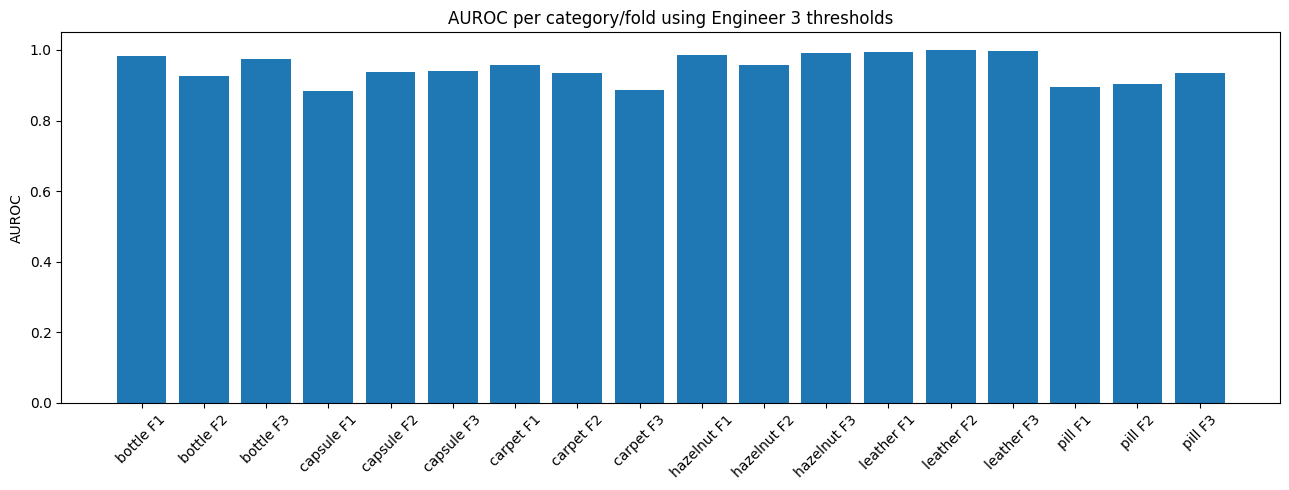

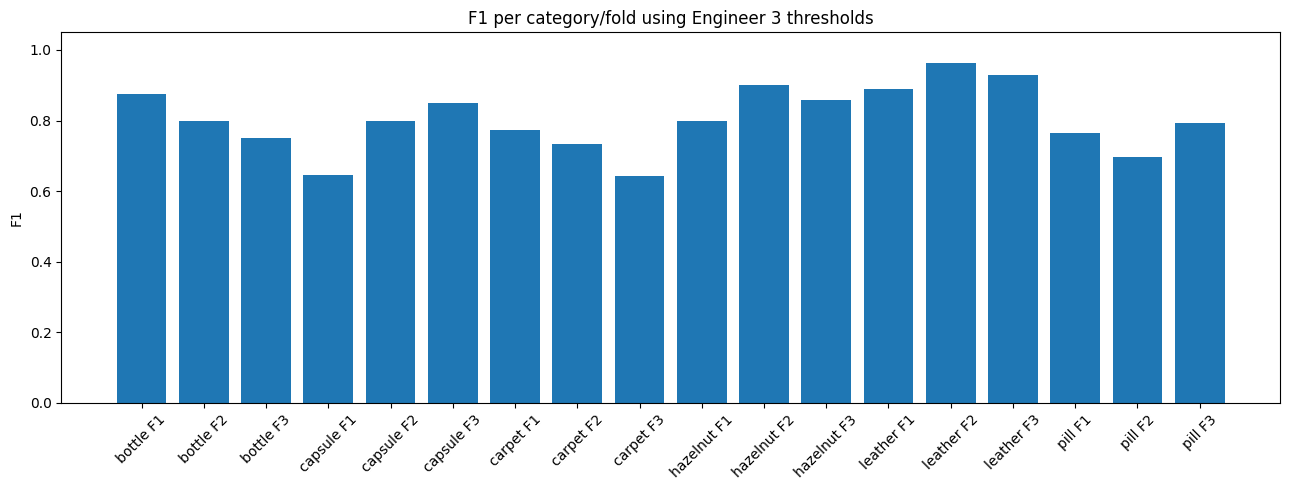

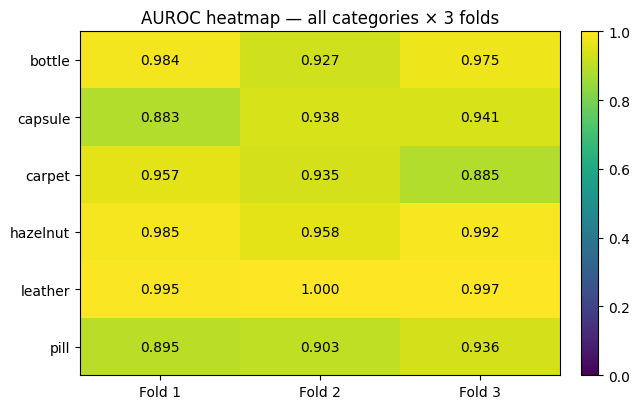

In [17]:
if len(all_folds_df) > 0:
    plot_df = all_folds_df.sort_values(["category", "fold"]).copy()
    plot_df["label"] = plot_df["category"] + " F" + plot_df["fold"].astype(str)

    # AUROC bar chart
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.bar(plot_df["label"], plot_df["auroc"])
    ax.set_ylim(0.0, 1.05)
    ax.set_ylabel("AUROC")
    ax.set_title("AUROC per category/fold using Engineer 3 thresholds")
    ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "all_folds_auroc_bar.png", dpi=160)
    plt.show()

    # F1 bar chart
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.bar(plot_df["label"], plot_df["f1"])
    ax.set_ylim(0.0, 1.05)
    ax.set_ylabel("F1")
    ax.set_title("F1 per category/fold using Engineer 3 thresholds")
    ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "all_folds_f1_bar.png", dpi=160)
    plt.show()

    # AUROC heatmap
    heatmap_df = all_folds_df.pivot(index="category", columns="fold", values="auroc").reindex(CATEGORIES)
    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    im = ax.imshow(heatmap_df.values, aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(len(heatmap_df.columns)), [f"Fold {c}" for c in heatmap_df.columns])
    ax.set_yticks(range(len(heatmap_df.index)), heatmap_df.index)
    ax.set_title("AUROC heatmap — all categories × 3 folds")

    for i in range(heatmap_df.shape[0]):
        for j in range(heatmap_df.shape[1]):
            value = heatmap_df.values[i, j]
            ax.text(j, i, f"{value:.3f}", ha="center", va="center")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "auroc_fold_heatmap.png", dpi=160)
    plt.show()
else:
    print("No successful folds to plot.")


## 9. Optional qualitative Grad-CAM and failure-case galleries

By default, `RUN_QUALITATIVE = False` to keep the all-fold quantitative evaluation stable and fast.

To generate qualitative outputs for all 18 folds, set `RUN_QUALITATIVE = True` in the parameters cell and rerun.


In [18]:
if RUN_QUALITATIVE and QUALITATIVE_AVAILABLE and len(all_folds_df) > 0:
    qualitative_errors = []
    start_time = time.time()

    for _, row in all_folds_df.iterrows():
        category = row["category"]
        fold_id = int(row["fold"])

        try:
            print(f"\\nGenerating qualitative outputs for {category} fold {fold_id}")
            dataloader, _ = build_test_dataloader(category, fold_id)
            checkpoint_path = Path(row["checkpoint_path"])
            model = DefectClassifier.load_from_checkpoint(checkpoint_path, map_location=DEVICE)

            gallery_output_dir = OUTPUT_DIR / "galleries" / category / f"fold{fold_id}"
            gallery_output_dir.mkdir(parents=True, exist_ok=True)

            gradcam_path, failure_path = run_qualitative_for_category(
                model=model,
                dataloader=dataloader,
                category=f"{category}_fold{fold_id}",
                output_dir=gallery_output_dir,
                device=DEVICE,
                n_per_class=QUAL_N_PER_CLASS,
                n_worst=QUAL_N_WORST,
            )

            print("Saved:", gradcam_path)
            print("Saved:", failure_path)

            del model
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        except Exception as e:
            print(f"Qualitative ERROR for {category} fold {fold_id}: {repr(e)}")
            qualitative_errors.append({
                "category": category,
                "fold": fold_id,
                "error": repr(e),
            })

    elapsed = time.time() - start_time
    print(f"\\nFinished qualitative generation in {timedelta(seconds=int(elapsed))}")

    if qualitative_errors:
        qualitative_error_df = pd.DataFrame(qualitative_errors)
        qualitative_error_df.to_csv(OUTPUT_DIR / "qualitative_errors.csv", index=False)
        display(qualitative_error_df)
else:
    print("Qualitative generation skipped.")
    print("RUN_QUALITATIVE:", RUN_QUALITATIVE)
    print("QUALITATIVE_AVAILABLE:", QUALITATIVE_AVAILABLE)


Qualitative generation skipped.
RUN_QUALITATIVE: False
QUALITATIVE_AVAILABLE: True


## 10. Saved outputs

In [20]:
print("Output directory:", OUTPUT_DIR)

if OUTPUT_DIR.exists():
    print("\\nSaved files:")
    for path in sorted(OUTPUT_DIR.rglob("*")):
        if path.is_file():
            print(path.relative_to(OUTPUT_DIR))

print("\\nMain result files:")
print("- all_folds_results.csv")
print("- all_folds_results.json")
print("- all_folds_results.md")
print("- category_mean_results.csv")
print("- category_mean_results.md")
print("- all_folds_auroc_bar.png")
print("- all_folds_f1_bar.png")
print("- auroc_fold_heatmap.png")
print("- per-fold metrics.json / predictions.csv / ROC / PR / confusion matrices")


Output directory: /kaggle/working/eval_results_all_folds
\nSaved files:
all_folds_auroc_bar.png
all_folds_f1_bar.png
all_folds_results.csv
all_folds_results.json
all_folds_results.md
auroc_fold_heatmap.png
bottle/fold1/confusion_matrix.png
bottle/fold1/metrics.json
bottle/fold1/pr_curve.png
bottle/fold1/predictions.csv
bottle/fold1/roc_curve.png
bottle/fold2/confusion_matrix.png
bottle/fold2/metrics.json
bottle/fold2/pr_curve.png
bottle/fold2/predictions.csv
bottle/fold2/roc_curve.png
bottle/fold3/confusion_matrix.png
bottle/fold3/metrics.json
bottle/fold3/pr_curve.png
bottle/fold3/predictions.csv
bottle/fold3/roc_curve.png
capsule/fold1/confusion_matrix.png
capsule/fold1/metrics.json
capsule/fold1/pr_curve.png
capsule/fold1/predictions.csv
capsule/fold1/roc_curve.png
capsule/fold2/confusion_matrix.png
capsule/fold2/metrics.json
capsule/fold2/pr_curve.png
capsule/fold2/predictions.csv
capsule/fold2/roc_curve.png
capsule/fold3/confusion_matrix.png
capsule/fold3/metrics.json
capsule/fold